<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 88 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Manufacturing Quality 🏭</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">A factory line that looks on-target on average hides two real problems. We explore by line and shift first, then use statsmodels for the one-sample spec test, the ANOVA with Tukey, and a defect-by-shift chi-square, and close the Part.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it does the standard errors,
# test statistics, intervals, and post-hoc comparisons for us, so we write far less by-hand code.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
pd.set_option("display.width",120)
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(88)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · EXPLORE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Look at the whole, then at each line and shift</div>
<div style="color:#4a5578;margin-top:6px">The headline number (overall mean weight) looks fine, so exploration is what saves us: we break weight down BY LINE and defects BY SHIFT before any test. Slicing the data is how a statistician spots problems an aggregate hides.</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch88_manufacturing_quality.xlsx", sheet_name="Units")
except FileNotFoundError: d = pd.read_excel(BASE+"ch88_manufacturing_quality.xlsx", sheet_name="Units")
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(f"overall mean weight = {d.fill_weight_g.mean():.2f} g (target 250)  <- looks on target")
print("\nbut BY LINE:"); print(d.groupby("line").fill_weight_g.agg(["mean","std"]).round(2))
print("\ndefect rate BY SHIFT:", {k: f"{v:.1%}" for k,v in d.groupby(d["shift"]).defect.mean().items()})

shape: (330, 6) | missing: 0
overall mean weight = 249.85 g (target 250)  <- looks on target

but BY LINE:
          mean   std
line                
Line-1  250.50  2.57
Line-2  248.67  2.77
Line-3  250.38  2.78

defect rate BY SHIFT: {'day': '6.0%', 'night': '19.6%'}


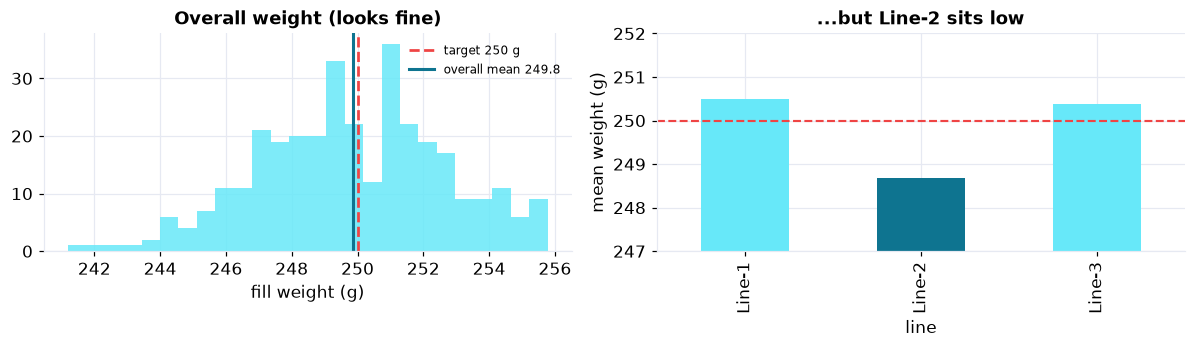

In [3]:
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].hist(d.fill_weight_g, bins=26, color=LIGHT, alpha=0.85)
ax[0].axvline(250, color=RED, lw=1.8, ls="--", label="target 250 g")
ax[0].axvline(d.fill_weight_g.mean(), color=DEEP, lw=2, label=f"overall mean {d.fill_weight_g.mean():.1f}")
ax[0].set_xlabel("fill weight (g)"); ax[0].set_title("Overall weight (looks fine)"); ax[0].legend(fontsize=8)
d.groupby("line").fill_weight_g.mean().plot(kind="bar", ax=ax[1], color=[LIGHT,DEEP,LIGHT])
ax[1].axhline(250,color=RED,lw=1.4,ls="--"); ax[1].set_ylim(247,252); ax[1].set_ylabel("mean weight (g)")
ax[1].set_title("...but Line-2 sits low"); plt.tight_layout(); plt.show()

The aggregate is reassuring, but the by-line and by-shift slices already hint at two problems: Line-2 looks light, and night defects look high. Exploration flagged them; now we test whether they are real.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · THREE QUESTIONS, THREE TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Spec, lines, and defects</div>
<div style="color:#4a5578;margin-top:6px">Q1 mean weight vs a TARGET -> one-sample t-test against 250. Q2 weight across THREE lines -> one-way ANOVA (+Tukey). Q3 defect (yes/no) by shift -> chi-square. Q1 and Q2 are different questions: the process can be on target ON AVERAGE while lines drift in opposite directions.</div>
</div>

In [4]:
print("Q1 mean weight vs 250 g  -> ONE-SAMPLE t-test | H0: mu=250    H1: mu!=250")
print("Q2 weight across 3 lines  -> ONE-WAY ANOVA+Tukey | H0: lines equal H1: a line differs")
print("Q3 defect rate by shift   -> CHI-SQUARE          | H0: independent H1: associated")

Q1 mean weight vs 250 g  -> ONE-SAMPLE t-test | H0: mu=250    H1: mu!=250
Q2 weight across 3 lines  -> ONE-WAY ANOVA+Tukey | H0: lines equal H1: a line differs
Q3 defect rate by shift   -> CHI-SQUARE          | H0: independent H1: associated


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">statsmodels for the spec test, ANOVA, and Tukey</div>
<div style="color:#4a5578;margin-top:6px">DescrStatsW tests the overall mean against spec and gives its CI; ols + anova_lm and pairwise_tukeyhsd handle the lines (no hand-coded Tukey); scipy's chi2_contingency tests defects by shift.</div>
</div>

In [5]:
# Q1 one-sample t-test vs the 250 g target, with CI, from statsmodels
ds=DescrStatsW(d.fill_weight_g.values)
t1,p1,_=ds.ttest_mean(250)
print(f"Q1 overall mean = {d.fill_weight_g.mean():.2f} g, t={t1:.2f}, p={p1:.3f}, 95% CI {tuple(round(float(v),2) for v in ds.tconfint_mean())}  -> {'on target' if p1>=0.05 else 'off target'}")
# Q2 ANOVA + Tukey via statsmodels
model=ols("fill_weight_g ~ C(line)", data=d).fit()
aov=sm.stats.anova_lm(model, typ=2)
print(f"Q2 ANOVA across lines: F={aov.loc["C(line)","F"]:.2f}, p={aov.loc["C(line)","PR(>F)"]:.2e}")

Q1 overall mean = 249.85 g, t=-0.98, p=0.329, 95% CI (249.54, 250.15)  -> on target
Q2 ANOVA across lines: F=15.68, p=3.15e-07


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Line-1 Line-2  -1.8281   0.0 -2.6879 -0.9683   True
Line-1 Line-3  -0.1203 0.942 -0.9801  0.7396  False
Line-2 Line-3   1.7078   0.0   0.848  2.5677   True
---------------------------------------------------



Q3 defect rate: day 6.0% vs night 19.6%; chi2=12.83, dof=1, p=0.0003, min expected=17.9
   -> reject H0: defects depend on shift


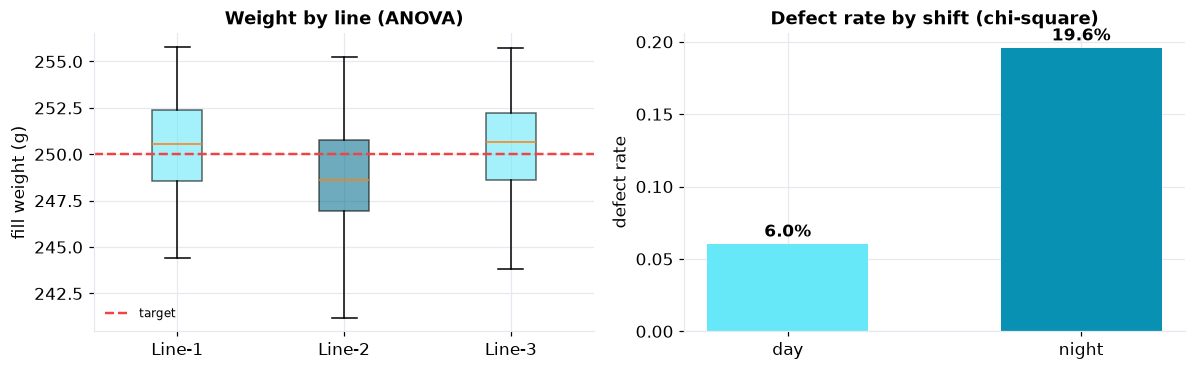

In [6]:
print(pairwise_tukeyhsd(d.fill_weight_g, d.line).summary())
# Q3 chi-square: defects by shift (use d["shift"] -- "shift" is also a DataFrame method!)
ct=pd.crosstab(d["shift"], d.defect)
chi2,p3,dof,expected=stats.chi2_contingency(ct)
day=d[d["shift"]=="day"].defect.mean(); night=d[d["shift"]=="night"].defect.mean()
print(f"\nQ3 defect rate: day {day:.1%} vs night {night:.1%}; chi2={chi2:.2f}, dof={dof}, p={p3:.4f}, min expected={expected.min():.1f}")
print("   -> reject H0: defects depend on shift" if p3<0.05 else "   independent")
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
order=["Line-1","Line-2","Line-3"]
bp=ax[0].boxplot([d[d.line==l].fill_weight_g.values for l in order], tick_labels=order, patch_artist=True)
for patch,l in zip(bp["boxes"],order): patch.set_facecolor(DEEP if l=="Line-2" else LIGHT); patch.set_alpha(0.6)
ax[0].axhline(250,color=RED,lw=1.6,ls="--",label="target"); ax[0].set_ylabel("fill weight (g)"); ax[0].set_title("Weight by line (ANOVA)"); ax[0].legend(fontsize=8)
ax[1].bar(["day","night"],[day,night],color=[LIGHT,CY],width=0.55)
for i,v in enumerate([day,night]): ax[1].text(i,v+0.005,f"{v:.1%}",ha="center",fontweight="bold")
ax[1].set_ylabel("defect rate"); ax[1].set_title("Defect rate by shift (chi-square)"); plt.tight_layout(); plt.show()

The whole lesson in one dataset. The overall mean (249.85 g) is statistically <strong>on target</strong> (p &#8776; 0.33), but the ANOVA says the lines differ (p &#8776; 10&#8315;&#8311;) and the Tukey table pins it on <strong>Line-2</strong> (light by ~1.7 g) while Lines 1 and 3 run slightly heavy, the errors cancel in the average. Separately, defects are <strong>three times higher at night</strong> (19.6% vs 6.0%, p &#8776; 0.0003).

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Findings: on-target on average, but two real problems</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> Overall the line hits its 250 g target on average, so a single headline number would say 'all good.' It is not. <strong>Line-2 is under-filling</strong> by about <strong>1.7 grams</strong> while Lines 1 and 3 run slightly heavy, the over- and under-fills cancel in the plant average but are real. And <strong>defects are about three times more common on the night shift</strong> (about 20% vs 6%). <br><br><strong>How confident are we?</strong> The line difference is highly unlikely to be chance (less than 1 in a million), and Tukey isolates Line-2. The night-shift defect difference is also clear (about 1 in 3,000 by chance). <br><br><strong>What to do.</strong> (1) Recalibrate Line-2&#39;s filler. (2) Investigate the night shift, staffing, fatigue, lighting, or maintenance timing. <br><br><strong>Caveats.</strong> The on-target average is a warning to monitor each line separately, not just the plant total. This is a one-time snapshot; set up ongoing control charts to catch drift as it happens.</div>
</div>

<div style="background:#ecfeff;border:1px solid #a5f3fc;border-radius:14px;padding:20px 24px;font-family:Inter,sans-serif">
<div style="font-size:18px;font-weight:800;color:#0e7490">🏁 That completes Part XIII</div>
<div style="color:#3f4a63;line-height:1.75;margin-top:6px">Across five case studies you explored each dataset first, chose the right test, ran it with the standard libraries (scipy + statsmodels, the Python answer to R/SAS), and reported an effect size and interval to a non-statistician. Next the book turns to <strong>relationships between variables</strong>: correlation and regression.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>